<a href="https://colab.research.google.com/github/vinayprabhu/DAMP/blob/main/notebooks/3_apex_verification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Goal

The goal of this notebook is to perform a sanity check of our inference pipeline by comparing the results with the academic-published data in the supplementary sections of the model-papers.

## List of checks performed:

- PRIMARY CHECKS: 4 MIC matrix ( Sequence x MIC/strain ) comparisons

  - 1 : APEX 1.0 - Venomics data verification
  - 2 : APEX 1.1 - Archaeomics data verification
  - 3 : APEX 1.1 - AMPDIFF data verification (DAD & AMPDIFF)

- SECONDARY CHECKS:  Checking the stats via thresholding

  - 1: APEX 1.0 and Extinctomics (<80 μmol l−1) and Venomics (<32 μmol l−1)
  - 2: APEX 1.1 and Archaeomics (<MIC ≤100 μmol l−1)
  - 3: APEX 1.1 and AMPDIFF (Reproducing the violin plots)

In [1]:
from google.colab import drive
import numpy as np
import os
import pandas as pd
# 1. Mount Google Drive to the default mount point
drive.mount("/content/drive")
project_dir="/content/drive/MyDrive/AMR/DAMP"
os.chdir(project_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
list_output=[f'./output/{fi}' for fi in os.listdir('./output/')]
list_output

['./output/df_apex_1_0.tsv',
 './output/df_apex_1_1.tsv',
 './output/df_macrel.tsv',
 './output/df_ai4amp.tsv',
 './output/df_amp_clip.tsv',
 './output/df_amp_read.tsv',
 './output/df_amplify.tsv',
 './output/df_mbc_attention.tsv',
 './output/df_deep_amp_cnn_neg.tsv',
 './output/df_deep_amp_cnn_pos.tsv',
 './output/df_deep_amp_lstm_neg.tsv',
 './output/df_deep_amp_lstm_pos.tsv',
 './output/df_ampredictor.tsv']

In [3]:
df_apex10_raw=pd.read_csv('./output/df_apex_1_0.tsv',sep='\t')
df_apex11_raw=pd.read_csv('./output/df_apex_1_1.tsv',sep='\t')

df_apex10_raw.shape , df_apex11_raw.shape

((190973, 35), (190973, 12))

In [4]:
list_verify=[f'./data/{fi}' for fi in os.listdir('./data_damp/') if 'verify' in fi]
list_verify

['./data/df_verify_venomics.tsv',
 './data/df_verify_archaeomics.tsv',
 './data/df_verify_dad.tsv',
 './data/df_verify_AMPDiff.tsv',
 './data/df_verify_human.tsv']


```
model_used,constraint,source_proteome
apex_1.0,MIC ≤ 80 μmol l−1,extinctome
apex_1.0,MIC ≤32 µmol L−1,venom_proteomes
apex_1.1,MIC ≤100 μmol l−1,archaeome
apex_1.1,MIC ≤ 64 μmol L−1,synthetic_sequence_space
Antimicrobial potency score by Pane et al,human_proteome
```


# 1 : Venomics data verification.
1. The authors had shared the exact MIC APEX 1.0 matrix that we read into ```
df_verify_venomics.tsv```
2. We also have our locally inferred APEX 1.0 values stored in ```df_apex_1_0.tsv```
3. Slice up ```df_apex_1_0.tsv``` and comapre the two matrices


In [5]:
df_published_venomics=pd.read_csv('./data/df_verify_venomics.tsv',sep='\t')
df_published_venomics.shape

(4618, 13)

In [6]:
col_apex1_inf=np.concatenate([np.arange(8),np.array([26,27,28])])+1
mat_published_venomics=df_published_venomics.iloc[:,np.arange(1,12)].values
mat_inference_venomics=df_apex10_raw.loc[df_apex10_raw.sequence.isin(df_published_venomics.Sequence.values),
                                         df_apex10_raw.columns[col_apex1_inf]].values
max_deviation_venomics=np.max(np.abs(mat_inference_venomics-mat_published_venomics))
max_deviation_venomics

np.float64(0.03297060546876196)

# 2: Archaeomics data verification.
1. The authors had shared the exact MIC APEX 1.1 values that we read into ```
df_verify_archaeomics.tsv```
2. We also have our locally inferred APEX 1.0 values stored in ```df_apex_1_1.tsv```
3. Slice up ```df_apex_1_1.tsv``` and compare the two matrices


In [7]:
df_published_archaeomics=pd.read_csv('./data/df_verify_archaeomics.tsv',sep='\t')
df_published_archaeomics.shape

(12623, 13)

In [8]:
col_=['Sequence']
col_.extend( list(df_published_archaeomics.columns[1:].values))
df_published_archaeomics.columns=col_

In [9]:
mat_published_archaeomics=df_published_archaeomics.iloc[:,1:-1].values
mat_inferred_archaeomics=df_apex11_raw.loc[df_apex11_raw.sequence.isin(df_published_archaeomics.Sequence.values),df_apex11_raw.columns[1:]].values
mat_published_archaeomics, mat_inferred_archaeomics

(array([[  5.299768 ,   6.92004  ,   8.106747 , ...,  28.437466 ,
          81.06784  ,   2.1262112],
        [  4.4421377,   8.4753275,   7.4186516, ...,  27.407877 ,
         107.06217  ,   4.368083 ],
        [  4.036451 ,   5.4259176,   4.326702 , ...,  44.171566 ,
         133.12457  ,   3.2396631],
        ...,
        [ 11.421593 ,  36.366814 ,  23.503574 , ..., 211.55136  ,
         359.30695  ,  24.611715 ],
        [ 11.814016 ,  48.039948 ,  30.639776 , ..., 203.2261   ,
         327.20703  ,  21.069641 ],
        [ 32.710327 ,  60.275574 ,  37.498737 , ..., 187.84581  ,
         301.77472  ,  45.35932  ]]),
 array([[  5.30175686,   6.92377806,   8.10779095, ...,  28.45728683,
          81.08416748,   2.12601018],
        [  4.44454718,   8.47921467,   7.42131853, ...,  27.41560364,
         107.07515717,   4.36863661],
        [  4.0362854 ,   5.424788  ,   4.32676077, ...,  44.17075729,
         133.09472656,   3.2386024 ],
        ...,
        [ 11.417099  ,  36.37407303,

In [10]:
error_archaemoics=np.mean(np.abs(mat_inferred_archaeomics-mat_published_archaeomics))
error_archaemoics

np.float64(0.01246778258332789)

# 3:  AMP-DIFF paper data verification - APEX 1.1 + (DAD & AMPDiff)

In [11]:
df_published_dad=pd.read_csv('./data_damp/df_verify_dad.tsv',sep='\t')
df_published_ampdiff=pd.read_csv('./data_damp/df_verify_AMPDiff.tsv',sep='\t')


df_inference_dad=df_apex11_raw.loc[df_apex11_raw.sequence.isin(df_published_dad.sequence.values),df_apex11_raw.columns[0:]]
df_inference_ampdiff=df_apex11_raw.loc[df_apex11_raw.sequence.isin(df_published_ampdiff.sequence.values),df_apex11_raw.columns[0:]]

In [12]:
df_published_dad.head(4)

,sequence,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC 13883,P. aeruginosa PA01,P. aeruginosa PA14,S. aureus ATCC 12600,S. aureus (ATCC BAA-1556) - MRSA,vancomycin-resistant E. faecalis ATCC 700802,vancomycin-resistant E. faecium ATCC 700221,average_MIC,ppl,molar_weight,charge,isoelectric_point,aromaticity,hydrophobicity,hydrophobic_moment
0,FFKKWPWWPWRRK,311.83276,350.54626,223.16974,115.971344,512.69460,436.09180,459.94125,498.13135,465.31375,524.23460,79.425095,361.577504,26.303656,1948.32,5.995,12.179688,0.461538,-0.278462,0.234824
1,RSVCRQIKICRRRGGCYYLCTNRPY,227.46667,310.24854,178.52353,276.092960,397.63280,333.55890,341.03897,425.70325,525.86640,470.94350,139.206100,329.661966,21.553949,3065.63,7.723,10.262939,0.120000,-0.413600,0.428818
2,PKTLRKFFARIRGGRAAVLNALGKEEQIGRASNSGRKCARKKK,94.80340,282.74527,114.55809,197.335570,347.64325,239.35048,236.06496,319.96450,394.00723,471.87756,96.055530,254.036894,17.972723,4769.60,12.930,12.046387,0.046512,-0.376047,0.198247
3,SNTALRRYNQWATGHFM,475.75348,503.65576,491.27188,507.683650,510.73117,511.33206,510.19193,507.62564,510.95834,512.98440,464.576420,500.614976,22.856602,2053.27,3.094,10.980469,0.176471,-0.138824,0.315313


In [13]:
df_inf_dad=df_inference_dad.set_index('sequence',inplace=False)
df_inf_dad.loc[df_published_dad.sequence.values]

,apex_1_1_A._baumannii_ATCC_19606,apex_1_1_E._coli_ATCC_11775,apex_1_1_E._coli_AIC221,apex_1_1_E._coli_AIC222,apex_1_1_K._pneumoniae_ATCC_13883,apex_1_1_P._aeruginosa_PA01,apex_1_1_P._aeruginosa_PA14,apex_1_1_S._aureus_ATCC_12600,apex_1_1_S._aureus_(ATCC_BAA-1556)_-_MRSA,apex_1_1_vancomycin-resistant_E._faecalis_ATCC_700802,apex_1_1_vancomycin-resistant_E._faecium_ATCC_700221
sequence,,,,,,,,,,,
FFKKWPWWPWRRK,311.832428,350.546021,223.169342,115.971420,512.694946,436.091553,459.940948,498.131378,465.313721,524.234619,79.425110
RSVCRQIKICRRRGGCYYLCTNRPY,227.466934,310.248779,178.523315,276.092987,397.632721,333.559052,341.039124,425.703522,525.866516,470.944031,139.206055
PKTLRKFFARIRGGRAAVLNALGKEEQIGRASNSGRKCARKKK,94.803268,282.745239,114.558083,197.335663,347.642975,239.350510,236.065033,319.964478,394.006897,471.877350,96.055511
SNTALRRYNQWATGHFM,475.753235,503.655945,491.271790,507.683655,510.731415,511.332092,510.191528,507.625488,510.958344,512.983826,464.576508
RCICVLGVC,406.046753,406.727264,446.285614,432.474945,450.624817,427.118561,463.168945,475.735626,525.628235,500.568420,408.179718
...,...,...,...,...,...,...,...,...,...,...,...
AIVVGGVMLGIIAGKNSGVDEAFFVLKQHHVEYGSDHRFEAD,458.415771,494.188965,499.065399,504.724365,507.197388,495.971802,504.115112,500.313782,497.907562,516.325439,456.053619
ERECDTDADCQKKFPGSNQHLLWCNNGFCDCRTH,482.232605,487.860840,495.703735,494.344421,489.739410,488.786346,492.196533,488.046753,514.009888,508.197571,484.411865
CRVPCNWKKEFGADC,501.620087,510.354553,474.301208,488.715515,508.764771,501.125397,492.885071,505.008881,510.090118,518.945129,485.946259


## DAD matrices verification

In [14]:
mat_published_dad=df_published_dad.iloc[:,1:-8].values
mat_inf_dad=df_inf_dad.loc[df_published_dad.sequence.values].values
np.mean(np.abs(mat_published_dad-mat_inf_dad))

np.float64(0.00013749123995381783)

## AMPDIFF matrices verification

In [15]:
df_inf_ampdiff=df_inference_ampdiff.set_index('sequence',inplace=False)
mat_inference_ampdiff=df_inf_ampdiff.loc[df_published_ampdiff.sequence.values].values
mat_published_ampdiff=df_published_ampdiff.iloc[:,1:-8].values
np.mean(np.abs(mat_inference_ampdiff-mat_published_ampdiff))

np.float64(0.008096568618909583)

# Secondary check -1 : APEX 1.0 and Extinctomics and Venomics

The Extinctomics and Venomics papers claimed that the APEX selected sequences all had MIC values less than the hand-selected threshold:

```
apex_1.0,MIC ≤ 80 μmol l−1,extinctome
apex_1.0,MIC ≤32 µmol L−1,venom_proteomes
```

Let us check that first:

In [16]:
df_damp=pd.read_csv('./data_damp/df_damp_190973x4.tsv',sep='\t')
df_apex10=pd.merge(df_damp.loc[:,[ 'source', 'model','sequence']],df_apex10_raw, on='sequence', how='inner')
APEX11_TO_APEX10 = [7, 0, 4, 5, 6, 1, 2, 3, 26, 27, 28]
col_34_strains=df_apex10.columns[3:].values
col_11_strains=df_apex10.columns[3:].values[APEX11_TO_APEX10]

In [17]:
(df_apex10.loc[df_apex10.source=='Extinctomics',col_34_strains].median(axis=1)<80).mean() , (df_apex10.loc[df_apex10.source=='Venomics',col_11_strains].median(axis=1)<32).mean()

(np.float64(0.9999462018506563), np.float64(0.9995669120831528))

# Secondary check -2a  : APEX 1.1 and Archaeomics

The Archaeomics paper claimed that the APEX selected sequences all had MIC values less than the hand-selected threshold:```apex_1.1,MIC ≤100 μmol l−1,archaeome```


Let us check that first:

In [18]:
df_apex11=pd.merge(df_damp.loc[:,[ 'source', 'model','sequence']],df_apex11_raw, on='sequence', how='inner')
df_apex11.head(4)

,source,model,sequence,apex_1_1_A._baumannii_ATCC_19606,apex_1_1_E._coli_ATCC_11775,apex_1_1_E._coli_AIC221,apex_1_1_E._coli_AIC222,apex_1_1_K._pneumoniae_ATCC_13883,apex_1_1_P._aeruginosa_PA01,apex_1_1_P._aeruginosa_PA14,apex_1_1_S._aureus_ATCC_12600,apex_1_1_S._aureus_(ATCC_BAA-1556)_-_MRSA,apex_1_1_vancomycin-resistant_E._faecalis_ATCC_700802,apex_1_1_vancomycin-resistant_E._faecium_ATCC_700221
0,Extinctomics,APEX_1.0,SINSLIIKLIQADILKNKLS,63.852989,519.161926,454.381561,462.990997,535.097412,538.894958,524.919983,483.755310,492.316223,528.917969,533.635742
1,Extinctomics,APEX_1.0,MARNLVRYVQGLKKKKVI,48.937965,424.378906,122.669678,155.880920,438.995636,170.603485,500.699432,510.114777,523.576782,522.340332,28.192482
2,Extinctomics,APEX_1.0,KWTKIYLPLLL,60.634514,519.496582,513.330566,508.349518,521.109863,516.243347,513.167847,522.296875,503.368774,506.994080,59.306801
3,Extinctomics,APEX_1.0,NLVRYVQGLKKKKVIVIPVGIG,48.362522,288.194824,272.619995,191.605911,470.119873,501.862640,481.800812,438.506195,482.496582,514.329834,209.146591


In [19]:
col_11_strains_apex11=df_apex11.columns[3:].values
print((df_apex11.loc[df_apex11.source=='Archaeomics',col_11_strains_apex11].mean(axis=1)<100).mean())

0.9994454567060128


# Secondary check -2b  : APEX 1.1 and AMPDiff : Reproducing violin plots

*"We collected 18,677 non-redundant reviewed protein sequences from 233
archaeal organisms available on UniProt10 and used APEX 1.1, a deep learning antimicrobial activity predictor6
 retrained on updated data (‘APEX 1.1’
in Methods), to mine EPs within archaeal proteomes. As APEX predicted
bacterial-strain-specific minimum inhibitory concentrations (MICs), we
used the mean MIC to represent the overall antimicrobial potency of the
peptides and found 12,623 EPs with a mean MIC ≤100 μmol l−1 (Fig. 1a and
Supplementary Data 1), representing an archaeasin ratio of 0.00653%
from the 193,331,608 archaeal peptides scanned. "*

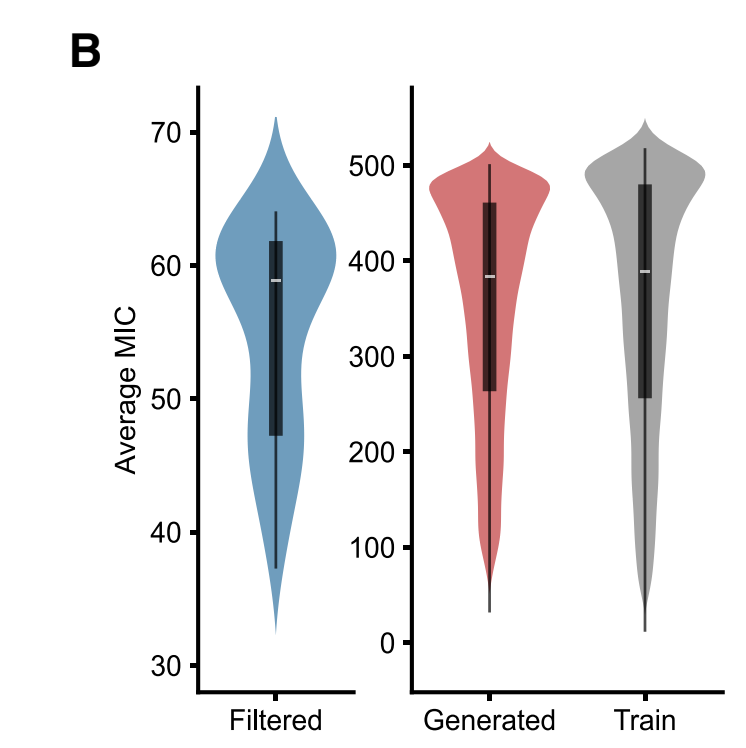

Let us try to reproduce this violin plot

In [20]:
df_generated=df_apex11.loc[df_apex11.source=='AMPDIFF_synth50k',col_11_strains_apex11]
df_generated.reset_index(drop=True,inplace=True)
df_train=df_apex11.loc[df_apex11.source=='DRAMP_APD_DBAASP',col_11_strains_apex11]
df_train.reset_index(drop=True,inplace=True)

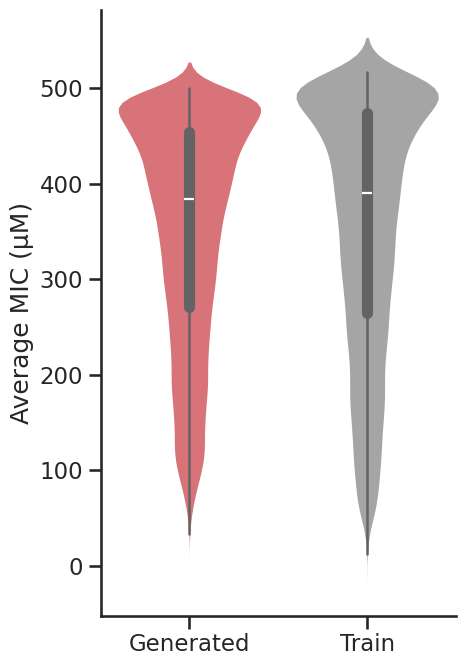

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
Generated,49986.0,353.11,117.51,33.13,270.68,384.09,453.99,499.99
Train,19622.0,357.69,129.67,12.95,264.60,389.79,473.24,516.72


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



data = pd.concat(
    [
        pd.DataFrame({"Group": name, "MIC": df.mean(axis=1).to_numpy()})
        for name, df in {
            "Generated": df_generated,
            "Train": df_train,
        }.items()
    ],
    ignore_index=True,
)

sns.set_theme(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(5, 7))

sns.violinplot(
    data=data, x="Group", y="MIC", hue="Group",
    order=["Generated", "Train"],
    palette={"Generated": "#D87379", "Train": "#A5A5A5"},
    legend=False, saturation=1, linewidth=0,
    inner="box", cut=2, bw_method="scott",
    density_norm="width",
    inner_kws={"box_width": 8, "whis_width": 1.8, "marker": "_"},
    ax=ax,
)

ax.set(xlabel="", ylabel="Average MIC (µM)")
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

# Exact statistics of the values plotted.
display(data.groupby("Group", sort=False)["MIC"].describe().round(2))